# Notebook 03 — SQL Business Analysis

## Project:
Customer Churn Prediction & Retention Analytics

## Company:
InsightFlow Analytics Ltd

## Objective:

Use SQL queries to analyse customer behaviour, churn patterns,
revenue impact, and support experience.

The analysis will answer key business questions:

1. How many customers have churned?
2. Which customer groups have the highest churn?
3. How much revenue is lost from churn?
4. Does customer behaviour differ between churned and retained customers?
5. Does support experience influence churn?

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
database_path = "/kaggle/input/datasets/neelamsingh1987/customer-churn-dataset/customer_churn_analytics.db"

conn = sqlite3.connect(database_path)

print("Database connection successful")

Database connection successful


## Step 3 Conclusion

The SQLite database connection has been successfully created.

Python can now communicate with the database and execute SQL queries for business analysis.

In [3]:
# Check available tables in the database
# This query lists all tables stored inside our SQLite database.

tables = pd.read_sql("""
SELECT name 
FROM sqlite_master
WHERE type='table';
""", conn)

tables

,name
0,customers
1,customer_behaviour
2,support_interactions


## Conclusion

The database structure has been successfully verified.

The three analytical tables available are:

- Customer information
- Customer behaviour data
- Support interaction data

These tables will be used together to answer business questions about customer churn.

In [4]:
# Display the structure of the customers table
# This shows column names, data types, and table information.

customers_structure = pd.read_sql("""
PRAGMA table_info(customers);
""", conn)

customers_structure

,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,0
1,1,signup_date,TIMESTAMP,0,None,0
2,2,region,TEXT,0,None,0
3,3,age_group,TEXT,0,None,0
4,4,subscription_type,TEXT,0,None,0
5,5,monthly_revenue,INTEGER,0,None,0
6,6,tenure_months,INTEGER,0,None,0
7,7,churn,INTEGER,0,None,0


## Customers Table Overview

The customers table contains the main customer profile information required for churn analysis.

Important fields include:

- Customer details
- Subscription information
- Revenue information
- Tenure
- Churn status

This table will be the foundation for our SQL business analysis.

In [5]:
# Display the first 5 records from the customers table
# This helps us visually inspect the customer data.

customers_sample = pd.read_sql("""
SELECT *
FROM customers
LIMIT 5;
""", conn)

customers_sample

,customer_id,signup_date,region,age_group,subscription_type,monthly_revenue,tenure_months,churn
0,10001,2023-01-31 00:00:00,London,60+,Professional,79,35,0
1,10002,2023-12-30 00:00:00,Leeds,18-25,Professional,79,24,0
2,10003,2022-05-10 00:00:00,Bristol,26-35,Basic,29,44,0
3,10004,2023-07-18 00:00:00,London,18-25,Basic,29,29,0
4,10005,2023-02-04 00:00:00,Manchester,60+,Basic,29,35,0


## Customer Data Check

The customer table has been successfully loaded and inspected.

The records contain the information required for churn analysis, including customer attributes, subscription details, revenue, and churn status.

We can now begin answering business questions using SQL.

## Customer Overview

Before analysing churn, we first need to understand the size of the customer base.

This query calculates the total number of customers in the database. It serves as the foundation for all subsequent business metrics and analyses.

In [6]:
# Count the total number of customers in the database.

total_customers = pd.read_sql("""
SELECT COUNT(*) AS total_customers
FROM customers;
""", conn)

total_customers

,total_customers
0,10000


## Business Insight

The database contains **10,000 customers**.

This figure represents the total customer population analysed throughout this project. All churn rates, revenue calculations, and customer behaviour analyses will be based on this customer base.

## Customer Churn Distribution

Understanding the number of retained and churned customers provides an overview of customer retention performance.

This query groups customers by their churn status and counts the number of customers in each group.

In [7]:
# Count customers by churn status.

churn_distribution = pd.read_sql("""
SELECT
    churn,
    COUNT(*) AS customer_count
FROM customers
GROUP BY churn;
""", conn)

churn_distribution

,churn,customer_count
0,0,8496
1,1,1504


## Business Insight

The customer base consists of **10,000 customers**, of which **8,496** have been retained and **1,504** have churned.

This represents a healthy customer retention rate; however, approximately **15%** of customers have left the service. Reducing this level of churn could significantly improve long-term revenue and customer lifetime value.

The next step is to calculate the exact churn rate as a percentage.

## Customer Churn Rate

While customer counts provide an overview of retention, calculating the churn rate gives a clearer measure of business performance.

This query calculates the percentage of customers who have churned from the total customer base.

In [8]:
# Calculate the overall customer churn rate.

churn_rate = pd.read_sql("""
SELECT
    ROUND((SUM(churn) * 100.0) / COUNT(*), 2) AS churn_rate_percentage
FROM customers;
""", conn)

churn_rate

,churn_rate_percentage
0,15.04


## Churn by Subscription Type

Different subscription plans may experience different levels of customer churn.

This analysis calculates the number of customers, the number of churned customers, and the churn rate for each subscription type.

In [9]:
# Calculate the churn rate for each subscription type.

subscription_churn = pd.read_sql("""
SELECT
    subscription_type,
    COUNT(*) AS total_customers,
    SUM(churn) AS churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY subscription_type
ORDER BY churn_rate DESC;
""", conn)

subscription_churn

,subscription_type,total_customers,churned_customers,churn_rate
0,Professional,4015,622,15.49
1,Enterprise,1425,210,14.74
2,Basic,4560,672,14.74


## Business Insight

The Professional subscription has the highest churn rate at **15.49%**, while the Basic and Enterprise plans both have a churn rate of **14.74%**.

Although the Professional plan experiences the highest churn, the difference between subscription types is relatively small. This suggests that subscription type alone is not a strong predictor of customer churn.

To better understand why customers leave, we should investigate behavioural factors such as product usage, customer engagement, and support experience.

## Churn by Region

Customer churn may vary across geographical regions due to differences in customer demographics, market conditions, or service experience.

This analysis calculates the churn rate for each region to identify whether any location experiences significantly higher customer churn.

In [10]:
# Calculate the churn rate for each region.

region_churn = pd.read_sql("""
SELECT
    region,
    COUNT(*) AS total_customers,
    SUM(churn) AS churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY region
ORDER BY churn_rate DESC;
""", conn)

region_churn

,region,total_customers,churned_customers,churn_rate
0,London,3040,487,16.02
1,Bristol,1017,157,15.44
2,Leeds,1442,218,15.12
3,Glasgow,980,148,15.10
4,Manchester,2033,297,14.61
5,Birmingham,1488,197,13.24


## Business Insight

Customer churn rates are relatively consistent across all regions, ranging from **13.24%** to **16.02%**.

London has the highest churn rate (**16.02%**), while Birmingham has the lowest (**13.24%**). However, the differences between regions are relatively small, suggesting that geographic location is not a major driver of customer churn.

Further analysis should focus on customer behaviour and support experience, which are more likely to influence retention.

## Churn by Customer Tenure

Customer tenure measures how long a customer has remained with the company.

This analysis groups customers into tenure categories and calculates the churn rate for each group to determine whether longer-term customers are more likely to remain loyal.

In [11]:
# Calculate the churn rate by customer tenure group.

tenure_churn = pd.read_sql("""
SELECT
    CASE
        WHEN tenure_months BETWEEN 1 AND 24 THEN '1–24 Months'
        WHEN tenure_months BETWEEN 25 AND 48 THEN '25–48 Months'
        ELSE '49–72 Months'
    END AS tenure_group,
    COUNT(*) AS total_customers,
    SUM(churn) AS churned_customers,
    ROUND(AVG(churn) * 100, 2) AS churn_rate
FROM customers
GROUP BY tenure_group
ORDER BY tenure_group;
""", conn)

tenure_churn

,tenure_group,total_customers,churned_customers,churn_rate
0,1–24 Months,2112,312,14.77
1,25–48 Months,3999,591,14.78
2,49–72 Months,3889,601,15.45


## Business Insight

Customer churn remains relatively consistent across all tenure groups, ranging from **14.77%** to **15.45%**.

Customers with **49–72 months** of tenure have the highest churn rate (**15.45%**), while newer customers (**1–24 months**) have the lowest (**14.77%**). However, the differences are minimal.

These findings suggest that customer tenure alone is not a strong predictor of churn. To better understand why customers leave, it is more valuable to analyse behavioural and support-related factors.

# Customer Overview & Churn Analysis Summary

The SQL analysis shows that customer churn is relatively consistent across different subscription plans, regions, and tenure groups.

Although small differences exist, none of these customer characteristics appear to be strong predictors of churn. This suggests that demographic and account-level attributes have a limited influence on customer retention.

The next section focuses on the financial impact of churn by analysing revenue loss, followed by customer behaviour and support metrics to identify stronger indicators of churn.

# Revenue Analysis

Customer churn directly affects business revenue and profitability.

In this section, we analyse how monthly revenue is distributed between retained and churned customers to understand the financial impact of customer attrition.

## Monthly Revenue by Customer Status

This query calculates the total monthly revenue generated by retained and churned customers.

Comparing these figures helps estimate the amount of recurring revenue currently at risk due to customer churn.

In [12]:
# Calculate total monthly revenue by customer status.

revenue_by_churn = pd.read_sql("""
SELECT
    churn,
    COUNT(*) AS total_customers,
    SUM(monthly_revenue) AS total_monthly_revenue,
    ROUND(AVG(monthly_revenue), 2) AS average_monthly_revenue
FROM customers
GROUP BY churn;
""", conn)

revenue_by_churn

,churn,total_customers,total_monthly_revenue,average_monthly_revenue
0,0,8496,622584,73.28
1,1,1504,110416,73.41


## Business Insight

Retained customers generate **£622,584** in monthly recurring revenue, while churned customers account for **£110,416** in lost monthly revenue.

The average monthly revenue per customer is almost identical for both retained (£73.28) and churned (£73.41) customers. This indicates that customer churn affects all revenue segments rather than being concentrated among either high-value or low-value customers.

Reducing churn would therefore protect a substantial amount of recurring revenue and improve the company's long-term financial performance.

## Revenue Lost from Churn

Customer churn has a direct impact on recurring revenue.

This analysis calculates the total monthly revenue associated with churned customers to estimate the financial exposure caused by customer loss.

In [13]:
# Calculate monthly revenue lost from churned customers.

revenue_lost = pd.read_sql("""
SELECT
    SUM(monthly_revenue) AS revenue_lost_from_churn
FROM customers
WHERE churn = 1;
""", conn)

revenue_lost

,revenue_lost_from_churn
0,110416


## Business Insight

Customer churn is currently resulting in **£110,416 of lost monthly recurring revenue**.

This represents a significant revenue opportunity for InsightFlow Analytics. Reducing churn by improving customer engagement, product adoption, and support experience could directly protect recurring revenue.

The next analysis will identify which subscription plans contribute the most revenue loss from churn.

## Revenue Lost by Subscription Type

Different subscription plans generate different levels of revenue.

This analysis calculates the revenue lost from churned customers across each subscription type to identify where retention efforts could have the greatest financial impact.

In [14]:
# Calculate revenue lost from churned customers by subscription type.

revenue_loss_subscription = pd.read_sql("""
SELECT
    subscription_type,
    COUNT(*) AS churned_customers,
    SUM(monthly_revenue) AS revenue_lost
FROM customers
WHERE churn = 1
GROUP BY subscription_type
ORDER BY revenue_lost DESC;
""", conn)

revenue_loss_subscription

,subscription_type,churned_customers,revenue_lost
0,Professional,622,49138
1,Enterprise,210,41790
2,Basic,672,19488


## Business Insight

The Professional subscription generates the highest revenue loss from churn, with **£49,138 in lost monthly recurring revenue**, followed by Enterprise customers with **£41,790**.

Although Basic customers have the highest number of churned customers (**672 customers**), their lower subscription value results in a smaller revenue impact (**£19,488**).

This highlights that retention strategies should consider both:

- Number of customers at risk
- Revenue value of those customers

Professional and Enterprise customers should receive particular attention because preventing churn in these segments could have the greatest financial benefit.

# Customer Behaviour Analysis

Customer engagement is a key factor in customer retention.

This section compares behavioural metrics between retained and churned customers to identify differences in product usage and engagement patterns.

## Monthly Login Activity

This analysis compares the average monthly login count between retained and churned customers.

A significant difference may indicate that reduced product engagement is associated with higher churn risk.

In [15]:
# Display the structure of the customer_behaviour table
# This shows which engagement metrics are available for analysis.

behaviour_structure = pd.read_sql("""
PRAGMA table_info(customer_behaviour);
""", conn)

behaviour_structure


,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,0
1,1,month,TIMESTAMP,0,None,0
2,2,monthly_login_count,INTEGER,0,None,0
3,3,average_session_time_minutes,REAL,0,None,0
4,4,features_used,INTEGER,0,None,0
5,5,last_login_days_ago,INTEGER,0,None,0
6,6,usage_frequency,TEXT,0,None,0


In [16]:
# Compare average monthly logins between retained and churned customers.
# The tables are joined using customer_id.

login_activity = pd.read_sql("""
SELECT
    c.churn,
    ROUND(AVG(cb.monthly_login_count), 2) AS average_monthly_logins
FROM customers c
JOIN customer_behaviour cb
    ON c.customer_id = cb.customer_id
GROUP BY c.churn;
""", conn)

login_activity

,churn,average_monthly_logins
0,0,14.98
1,1,15.02


## Business Insight

Average monthly login activity is very similar between retained and churned customers.

- Retained customers: **14.98 average monthly logins**
- Churned customers: **15.02 average monthly logins**

This suggests that login frequency alone is not a strong churn indicator within this dataset.

Although engagement is often an important factor in customer retention, other behavioural metrics such as feature adoption, inactivity periods, and customer satisfaction may provide stronger explanations for churn.

In [17]:
# Compare average feature usage between retained and churned customers.

feature_usage = pd.read_sql("""
SELECT
    c.churn,
    ROUND(AVG(cb.features_used), 2) AS average_features_used
FROM customers c
JOIN customer_behaviour cb
    ON c.customer_id = cb.customer_id
GROUP BY c.churn;
""", conn)

feature_usage

,churn,average_features_used
0,0,5.01
1,1,4.99


## Business Insight

Feature adoption is also very similar between retained and churned customers.

- Retained customers: **5.01 average features used**
- Churned customers: **4.99 average features used**

The small difference suggests that feature usage alone is not a strong churn indicator in the current database analysis.

This highlights the importance of analysing multiple factors together rather than relying on a single customer behaviour metric. Additional factors such as customer satisfaction, complaints, and support experience may provide stronger explanations for churn.

In [18]:
# Compare average days since last login between retained and churned customers.

login_recency = pd.read_sql("""
SELECT
    c.churn,
    ROUND(AVG(cb.last_login_days_ago), 2) AS average_days_since_last_login
FROM customers c
JOIN customer_behaviour cb
    ON c.customer_id = cb.customer_id
GROUP BY c.churn;
""", conn)

login_recency


,churn,average_days_since_last_login
0,0,29.39
1,1,29.64


## Business Insight

The average time since last login is almost identical between retained and churned customers.

- Retained customers: **29.39 days since last login**
- Churned customers: **29.64 days since last login**

The small difference indicates that login recency is not a strong churn indicator within this database.

The SQL analysis suggests that individual engagement metrics alone may not explain customer churn. A combination of multiple factors, including customer satisfaction, complaints, support experience, and revenue value, should be considered when identifying customers at risk.

# Customer Behaviour Analysis Summary

The SQL analysis of customer behaviour metrics shows minimal differences between retained and churned customers.

Key findings:

- Average monthly logins are almost identical between customer groups.
- Feature adoption levels are very similar.
- Last login activity shows only a small difference.

These results indicate that individual behavioural metrics do not strongly explain churn within the database. This suggests that churn prediction should consider multiple customer attributes together rather than relying on single indicators.

# Support Experience Analysis

Customer support quality can influence customer satisfaction and retention.

This section compares support-related metrics between retained and churned customers to identify whether service experience is associated with customer churn.

In [19]:
# Display the structure of the support interactions table.

support_structure = pd.read_sql("""
PRAGMA table_info(support_interactions);
""", conn)

support_structure

,cid,name,type,notnull,dflt_value,pk
0,0,ticket_id,INTEGER,0,None,0
1,1,customer_id,INTEGER,0,None,0
2,2,issue_category,TEXT,0,None,0
3,3,complaint_count,INTEGER,0,None,0
4,4,response_time_hours,REAL,0,None,0
5,5,resolution_time_hours,REAL,0,None,0
6,6,customer_satisfaction_score,INTEGER,0,None,0


In [20]:
# Compare average complaint levels between retained and churned customers.
# The tables are joined using customer_id.

complaints_churn = pd.read_sql("""
SELECT
    c.churn,
    ROUND(AVG(s.complaint_count), 2) AS average_complaints
FROM customers c
JOIN support_interactions s
    ON c.customer_id = s.customer_id
GROUP BY c.churn;
""", conn)

complaints_churn

,churn,average_complaints
0,0,1.50
1,1,1.55


## Business Insight

Average complaint levels are almost identical between retained and churned customers.

- Retained customers: **1.50 average complaints**
- Churned customers: **1.55 average complaints**

Although churned customers show slightly higher complaint levels, the difference is very small. This suggests that complaint volume alone is not a strong churn indicator within this dataset.

Further analysis of support quality metrics, particularly resolution time and customer satisfaction, may provide stronger insights into customer retention.

In [21]:
# Compare average support response time between retained and churned customers.

response_time_churn = pd.read_sql("""
SELECT
    c.churn,
    ROUND(AVG(s.response_time_hours), 2) AS average_response_time_hours
FROM customers c
JOIN support_interactions s
    ON c.customer_id = s.customer_id
GROUP BY c.churn;
""", conn)

response_time_churn

,churn,average_response_time_hours
0,0,16.15
1,1,16.04


## Business Insight

Average response times are almost identical between retained and churned customers.

- Retained customers: **16.15 hours**
- Churned customers: **16.04 hours**

The results suggest that response time alone is not a strong driver of customer churn within this dataset.

While fast responses remain important for customer service quality, other support factors such as issue resolution effectiveness and customer satisfaction may provide stronger indicators of churn risk.

In [22]:
# Compare average issue resolution time between retained and churned customers.

resolution_time_churn = pd.read_sql("""
SELECT
    c.churn,
    ROUND(AVG(s.resolution_time_hours), 2) AS average_resolution_time_hours
FROM customers c
JOIN support_interactions s
    ON c.customer_id = s.customer_id
GROUP BY c.churn;
""", conn)

resolution_time_churn

,churn,average_resolution_time_hours
0,0,44.28
1,1,44.06


## Business Insight

Average resolution times are almost identical between retained and churned customers.

- Retained customers: **44.28 hours**
- Churned customers: **44.06 hours**

The results suggest that resolution time alone is not a strong churn indicator within this dataset.

Although efficient issue resolution remains important for customer service quality, churn appears to be influenced by a combination of factors rather than a single support metric.

In [23]:
# Compare average customer satisfaction between retained and churned customers.

satisfaction_churn = pd.read_sql("""
SELECT
    c.churn,
    ROUND(AVG(s.customer_satisfaction_score), 2) AS average_satisfaction_score
FROM customers c
JOIN support_interactions s
    ON c.customer_id = s.customer_id
GROUP BY c.churn;
""", conn)

satisfaction_churn

,churn,average_satisfaction_score
0,0,5.50
1,1,5.51


## Business Insight

Customer satisfaction scores are almost identical between retained and churned customers.

- Retained customers: **5.50 average satisfaction score**
- Churned customers: **5.51 average satisfaction score**

The results suggest that satisfaction score alone is not a strong churn indicator within this dataset.

Although customer satisfaction is an important business metric, churn appears to be influenced by a combination of customer characteristics, engagement patterns, and service experiences rather than one individual factor.

# Support Experience Analysis Summary

The SQL analysis explored whether support-related factors were associated with customer churn.

Key findings:

- Complaint levels were almost identical between retained and churned customers.
- Response times showed minimal difference between customer groups.
- Resolution times were also very similar.
- Customer satisfaction scores did not significantly differ.

These results suggest that support experience metrics alone do not explain customer churn within this dataset.

A combination of multiple customer attributes will likely be required to accurately identify customers at risk of leaving.

# SQL Business Analysis Conclusion

## Overview

The SQL analysis investigated customer churn patterns, financial impact, customer behaviour, and support experience using the InsightFlow Analytics customer database.

The analysis shows that customer churn affects both revenue and customer retention performance, but no single customer attribute explains why customers leave.

---

## Key Findings

### Customer Churn

- The overall customer churn rate is **15.04%**.
- Out of 10,000 customers, **1,504 customers have churned**.

### Revenue Impact

- Churned customers represent **£110,416 in lost monthly recurring revenue**.
- Professional customers contribute the highest revenue loss from churn (**£49,138**).

### Customer Characteristics

- Subscription type, region, and tenure show only small differences in churn rates.
- These factors alone are not strong predictors of customer churn.

### Customer Behaviour

- Monthly login activity showed minimal differences between retained and churned customers.
- Feature usage levels were also similar across customer groups.
- Individual engagement metrics alone do not fully explain churn.

### Support Experience

- Complaint levels, response times, resolution times, and satisfaction scores showed minimal differences between retained and churned customers.
- Support metrics alone are not sufficient to identify churn risk.

---

## Business Recommendations

Based on the analysis, InsightFlow Analytics should:

### 1. Develop a Churn Prediction Model

Use multiple customer attributes together to identify customers at higher risk of leaving.

Potential features:

- Customer engagement
- Subscription information
- Revenue value
- Support interactions
- Customer history

### 2. Protect High-Value Customers

Prioritise retention efforts for customers generating higher recurring revenue, particularly Professional and Enterprise customers.

### 3. Build Early Warning Systems

Monitor changes in:

- Customer activity
- Product adoption
- Support interactions
- Satisfaction levels

### 4. Use Predictive Analytics for Proactive Retention

The next stage of the project will use machine learning techniques to predict which customers are most likely to churn and support targeted retention campaigns.

---

## Next Steps

The findings from this SQL analysis will be used as the foundation for:

1. Machine Learning Churn Prediction Model
2. Customer Risk Segmentation
3. Power BI Retention Dashboard
4. Final Business Recommendations Report

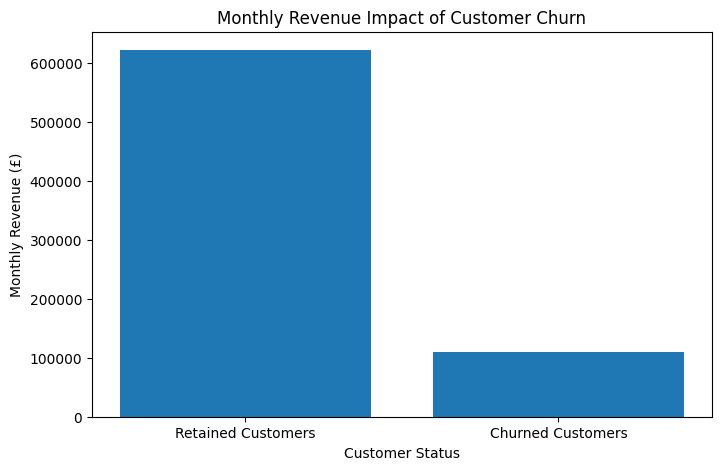

In [24]:
# Visualise monthly revenue contribution by customer status.

import matplotlib.pyplot as plt

# Create readable labels
revenue_chart = revenue_by_churn.copy()

revenue_chart["customer_status"] = revenue_chart["churn"].map({
    0: "Retained Customers",
    1: "Churned Customers"
})

plt.figure(figsize=(8,5))

plt.bar(
    revenue_chart["customer_status"],
    revenue_chart["total_monthly_revenue"]
)

plt.title("Monthly Revenue Impact of Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Revenue (£)")

plt.xticks(rotation=0)

plt.show()

## Chart Insight

The chart highlights the financial impact of customer churn.

Although churned customers represent a smaller proportion of the customer base, they account for **£110,416 in lost monthly recurring revenue**.

This demonstrates why reducing churn is a key business priority.

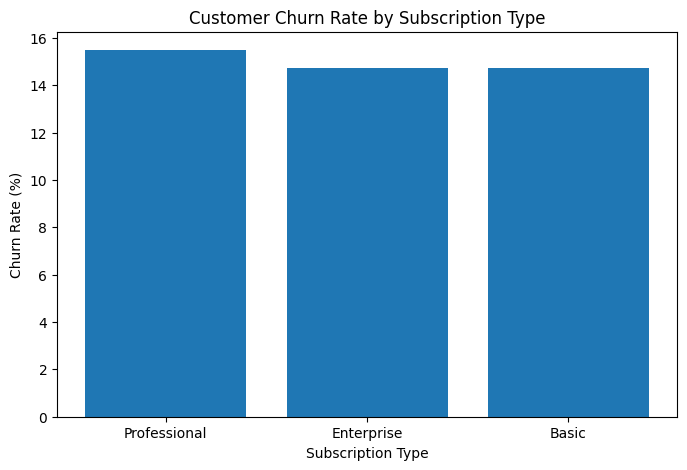

In [25]:
# Visualise churn rate by subscription type.

plt.figure(figsize=(8,5))

plt.bar(
    subscription_churn["subscription_type"],
    subscription_churn["churn_rate"]
)

plt.title("Customer Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)

plt.show()

## Chart Insight

The chart shows that churn rates are very similar across subscription plans.

Professional customers have the highest churn rate at **15.49%**, while Basic and Enterprise customers are both at **14.74%**.

The small difference suggests that subscription type alone is not a strong driver of customer churn.

Retention strategies should therefore focus on broader customer behaviours and experiences rather than subscription plan alone.

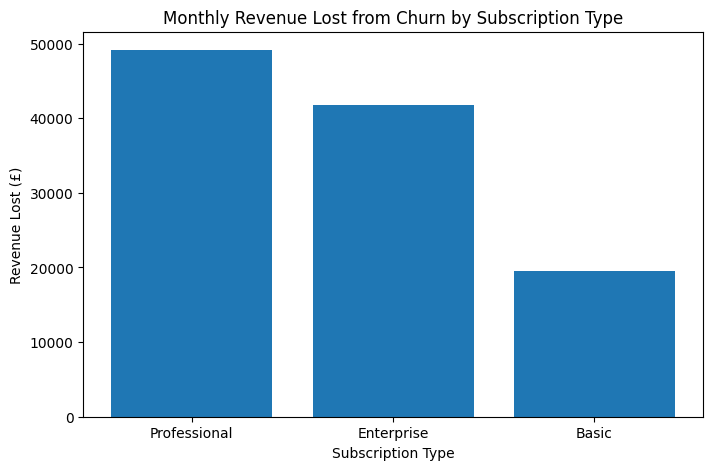

In [26]:
# Visualise revenue lost from churn by subscription type.

plt.figure(figsize=(8,5))

plt.bar(
    revenue_loss_subscription["subscription_type"],
    revenue_loss_subscription["revenue_lost"]
)

plt.title("Monthly Revenue Lost from Churn by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Revenue Lost (£)")

plt.xticks(rotation=0)

plt.show()

## Chart Insight

The chart highlights the financial impact of churn across subscription plans.

Professional customers contribute the highest revenue loss at **£49,138 per month**, followed by Enterprise customers at **£41,790**.

Although Basic customers have the highest number of churned customers, their lower subscription value results in a smaller financial impact.

This suggests that retention strategies should prioritise higher-value subscription customers to maximise revenue protection.

# Notebook 03 Summary

SQL analysis completed:
- Customer churn analysis
- Revenue impact analysis
- Customer behaviour analysis
- Support experience analysis
- Business recommendations